In [1]:
import os
import sys

# add the source directory to system path, so that relative imports work
# this fix is only for Jupyter Notebooks
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pykep

from tqdm import tqdm
from scipy.optimize import least_squares, direct

from orbital_mechanics.solar_system import SolarSystem
from common.constants import ALTAIRA_MU as MU, ALTAIRA_AU as AU, YEAR

# Find list of valid initial conditions

In [3]:
x0 = -200*AU   # initial x

ss = SolarSystem()
planetX = [pl for pl in ss.bodies if pl.name == 'PlanetX'][0]  # get PlanetX
print(planetX)

Id: 10
Type: planet
Weight: 50.0
Planet Name: PlanetX
Own gravity parameter: 3411912.3969999999
Central body gravity parameter: 139348062043.34299
Planet radius: 12993.799999999999
Planet safe radius: 14293.18
Keplerian planet elements: 
Semi major axis (AU): 0.10665270041384937
Eccentricity: 0.34499999999999997
Inclination (deg.): 40
Big Omega (deg.): 341.69299999999998
Small omega (deg.): 29.999999999999996
Mean anomaly (deg.): 133.42699999999999
Elements reference epoch: 2000-Jan-01 00:00:00
Ephemerides type: Keplerian
r at ref. = [-19776387679.20636, 5091000491.9670391, -1156782917.5597]
v at ref. = [-0.78096103990052712, -1.5132627939144223, -1.4113476643111722]



## Solve the Lambert problem

In [4]:
# cost function to make sure that initial velocity is towards +ve x
def costfun(tof, ry, rz, cw=False):
    r1 = np.array([x0, ry, rz])
    # find position of planetX at tof
    r2, _ = planetX.eph(tof*pykep.SEC2DAY); r2 = np.array(r2)

    # solve the 0-rev lambert problem
    l1 = pykep.lambert_problem(r1, r2, tof, MU, cw, 0)

    # calculate vy^2 + vz^2 and report the minimum
    v1 = np.array(l1.get_v1()[0])

    return float(v1[1]**2 + v1[2]**2), v1


In [5]:
# find a solution for a given tof
def solve_initial_cond(tof, cw=False):
    # do a global search
    res = direct(lambda x: costfun(tof, x[0], x[1], cw)[0], bounds=[(-100*AU, 100*AU), (-100*AU, 100*AU)])

    best_x = res['x']
    return best_x, costfun(tof, best_x[0], best_x[1], cw)[0]

## Build the database of initial conditions

In [6]:
import pandas as pd


db = pd.DataFrame(columns=['tof', 'acw_rx', 'acw_ry', 'acw_rz', 'acw_rmag',
                                 'acw_vx', 'acw_vy', 'acw_vz', 'acw_vmag', 'acw_cost',
                                 'cw_rx', 'cw_ry', 'cw_rz', 'cw_rmag',
                                 'cw_vx', 'cw_vy', 'cw_vz', 'cw_vmag', 'cw_cost'], dtype=np.float64)

print(db.head())

Empty DataFrame
Columns: [tof, acw_rx, acw_ry, acw_rz, acw_rmag, acw_vx, acw_vy, acw_vz, acw_vmag, acw_cost, cw_rx, cw_ry, cw_rz, cw_rmag, cw_vx, cw_vy, cw_vz, cw_vmag, cw_cost]
Index: []


In [7]:
num_points = 1000
tof_arr = np.linspace(10*YEAR, 190*YEAR, num_points)
db['tof'] = tof_arr   # preallocate db

for i in tqdm(range(len(tof_arr))):
    acw_pos, acw_cost = solve_initial_cond(tof_arr[i], False)
    _, acw_vel = costfun(tof_arr[i], *acw_pos, False)
    acw_pos = np.array([x0, *acw_pos])
    acw_pos_mag = np.linalg.norm(acw_pos)
    acw_vel_mag = np.linalg.norm(acw_vel)

    cw_pos, cw_cost = solve_initial_cond(tof_arr[i], True)
    _, cw_vel = costfun(tof_arr[i], *cw_pos, True)
    cw_pos = np.array([x0, *cw_pos])
    cw_pos_mag = np.linalg.norm(cw_pos)
    cw_vel_mag = np.linalg.norm(cw_vel)

    entry = pd.Series([tof_arr[i], *acw_pos, acw_pos_mag, *acw_vel, acw_vel_mag, acw_cost,
                       *cw_pos, cw_pos_mag, *cw_vel, cw_vel_mag, cw_cost], index=db.columns)
    
    db.loc[i] = entry

100%|███████████████████| 1000/1000 [00:06<00:00, 151.12it/s]


In [8]:
db.to_csv('initial_cond_db.csv')
print(db.head())

            tof        acw_rx         acw_ry         acw_rz      acw_rmag  \
0  3.155760e+08 -2.991957e+10 -619288.529715  206429.509905  2.991957e+10   
1  3.212621e+08 -2.991957e+10 -638054.848797  225195.828985  2.991957e+10   
2  3.269481e+08 -2.991957e+10 -656821.167879  225195.828985  2.991957e+10   
3  3.326342e+08 -2.991957e+10 -675587.486961  243962.148067  2.991957e+10   
4  3.383202e+08 -2.991957e+10 -713120.125126  243962.148067  2.991957e+10   

       acw_vx        acw_vy    acw_vz    acw_vmag      acw_cost         cw_rx  \
0  159.814376 -9.220333e-07  0.000047  159.814376  2.181198e-09 -2.991957e+10   
1  156.985600 -1.372461e-05 -0.000006  156.985600  2.229842e-10 -2.991957e+10   
2  154.255113 -2.767735e-05  0.000041  154.255113  2.465771e-09 -2.991957e+10   
3  151.617876 -4.270945e-05 -0.000007  151.617876  1.876698e-09 -2.991957e+10   
4  149.069187  3.473556e-05  0.000040  149.069187  2.845766e-09 -2.991957e+10   

          cw_ry         cw_rz       cw_rmag      c

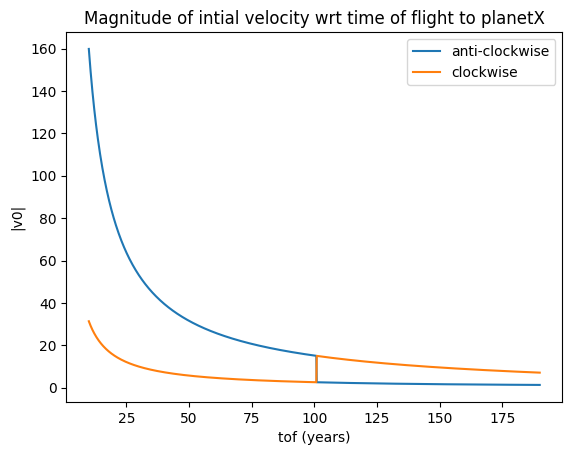

In [9]:
import matplotlib.pyplot as plt
plt.plot(db['tof']/YEAR, db['acw_vmag'], db['tof']/YEAR, db['cw_vmag'])
plt.xlabel('tof (years)')
plt.ylabel('|v0|')
plt.legend(['anti-clockwise', 'clockwise'])
plt.title('Magnitude of intial velocity wrt time of flight to planetX')
plt.show()

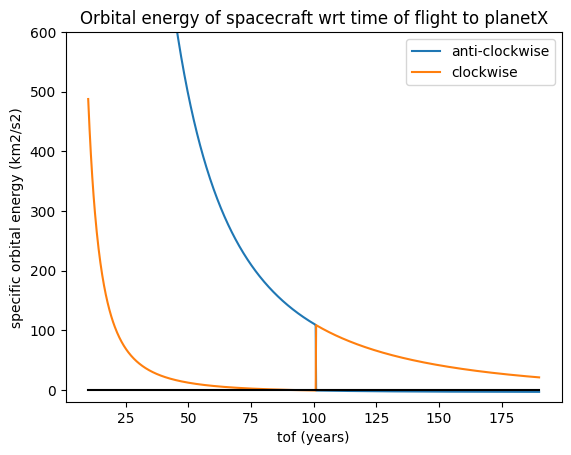

In [15]:
acw_energy = db['acw_vmag']**2/2 - MU/db['acw_rmag']
cw_energy = db['cw_vmag']**2/2 - MU/db['cw_rmag']

plt.plot(db['tof']/YEAR, acw_energy, db['tof']/YEAR, cw_energy)
plt.plot(db['tof']/YEAR, 0*db['tof']/YEAR, 'k')   # 0 energy
plt.xlabel('tof (years)')
plt.ylabel('specific orbital energy (km2/s2)')
plt.ylim((-20, 600))
plt.legend(['anti-clockwise', 'clockwise'])
plt.title('Orbital energy of spacecraft wrt time of flight to planetX')
plt.show()